# DataLoader

> Fastai DataLoader for spectroscopy data

In [ ]:
#| default_exp dataloader

In [ ]:
#| export
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
#from torch.utils.data import DataLoader, SubsetRandomSampler
#from fastai.data.core import DataLoaders
from fastai.torch_core import TensorBase
from fastai.data.block import DataBlock, TransformBlock
from kennard_stone import train_test_split as ks_split
from fastai.data.block import RegressionBlock
from fastai.torch_core import TitledFloat
from plum import dispatch

import logging
logging.getLogger('kennard_stone').setLevel(logging.WARNING)


In [4]:
#| export
def get_mir_k_1k_smp():
    "Load MIR Kex (exchangeable potassium) 1000 subsamples from OSSL"    
    url = "https://gist.githubusercontent.com/franckalbinet/613654a8908e5fa6bf131b9b267815f3/raw/0feb62ff4d0a26f2befb657aa87745b756de89b0/mir-k-subset-1000.csv"
    df = pd.read_csv(url)
    y = df.iloc[:, -1].to_numpy()
    X = df.iloc[:,:-1].to_numpy()
    wns = df.columns[:-1].to_numpy().astype(int)
    return X, y, wns

Loading toy data for usage examples:

In [5]:
#| eval: false
X, y, wns = get_mir_k_1k_smp()
X.shape, y.shape, wns[:5]

((1000, 1701), (1000,), array([600, 602, 604, 606, 608]))

## Splitters

In [6]:
#| export
def get_ks_splitter(test_size=0.1, valid_size=0.1):
    def _inner(X, y):
        train_val_X, test_X, train_val_idx, test_idx = ks_split(X, np.arange(len(X)), test_size=test_size)
        _, _, train_idx, valid_idx = ks_split(train_val_X, train_val_idx, test_size=valid_size / (1 - test_size))
        return train_idx, valid_idx, test_idx
    return _inner

In [7]:
#| eval: false
splitter = get_ks_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([729, 475, 677, 362, 222]),
 array([962, 601, 865,   6, 737]),
 array([929,  73, 881, 551, 894]))

In [10]:
#| export
def get_splitter(train_pct=0.8, valid_pct=0.1, seed=42):
    def _inner(X, y):
        if not np.isclose(train_pct + valid_pct + (1-train_pct-valid_pct), 1.0):
            raise ValueError("Split proportions must sum to 1")
        n = len(X)
        np.random.seed(seed)
        shuffled_idx = np.random.permutation(n)
        train_size = int(train_pct * n)
        valid_size = int(valid_pct * n)
        train_idx = shuffled_idx[:train_size]
        valid_idx = shuffled_idx[train_size:train_size + valid_size]
        test_idx = shuffled_idx[train_size + valid_size:]
        return train_idx, valid_idx, test_idx
    return _inner

In [11]:
#| eval: false
splitter = get_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([521, 737, 740, 660, 411]),
 array([556, 957, 577, 795,  85]),
 array([815, 862, 269, 201, 161]))

## Data loader

In [12]:
#| export
class SpectralTarget(TitledFloat):
    def show(self, ctx=None, **kwargs):
        if ctx is not None: ctx.set_title(f"Target: {self:.3f}")
        return ctx
        
    def __repr__(self): return f"{float(self):.3f}"

In [13]:
#| eval: false
SpectralTarget(2.345678)

2.346

In [14]:
#| export
class TensorSpectrum(TensorBase):
    wns = None  # set after loading data: TensorSpectrum.wns = wns

    def show(self, ctx=None, title=None, figsize=None, **kwargs):
        if ctx is None: _, ctx = plt.subplots(figsize=figsize)
        ctx.plot(self.__class__.wns, self.squeeze().cpu(), **kwargs)
        ctx.invert_xaxis()
        ctx.grid(True)
        if title is not None: ctx.set_title(f"Target value: {float(title):.3f}")
        return ctx
    
    def __repr__(self): return f"TensorSpectrum(shape={tuple(self.shape)})"

In [15]:
#| eval: false
TensorSpectrum(X[0])

TensorSpectrum(shape=(1701,))

In [16]:
#| export
@dispatch
def show_batch(
    x:TensorSpectrum, # Spectra (features)
    y, # Soil property (target)
    samples, 
    ctxs=None, 
    max_n=9, 
    ncols=3, 
    figsize=None, 
    **kwargs
    ):
    n = min(len(samples), max_n)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    if figsize is None: figsize = (6*ncols, 3*nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).flatten()
    for s, ax in zip(samples[:n], axs[:n]):
        s[0].show(ctx=ax, title=s[1], **kwargs)
    for ax in axs[n:]: ax.axis('off')
    plt.tight_layout()

In [17]:
#| export
def SpectralBlock():
    return TransformBlock(type_tfms=lambda x: TensorSpectrum(torch.tensor(x, dtype=torch.float32).unsqueeze(0)))

In [18]:
#| export
def RegressionFloatBlock():
    return TransformBlock(type_tfms=lambda x: SpectralTarget(x))

In [19]:
#| export
def get_spectral_dls(X, y, wns, splitter=None, bs=32):
    if splitter is None: splitter = get_splitter()
    TensorSpectrum.wns = wns
    train_idx, valid_idx, test_idx = splitter(X, y)
    items = list(range(len(X)))
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    dblock = DataBlock(
        blocks=(SpectralBlock(), RegressionBlock()),
        splitter=_ds_splitter,
        get_x=lambda i: X[i],
        get_y=lambda i: y[i],
    )
    return dblock.dataloaders(items, bs=bs), test_idx

In [20]:
#| eval: false
dls, test_idx = get_spectral_dls(X, y, wns)
# or with KS:
dls, test_idx = get_spectral_dls(X, y, wns, splitter=get_ks_splitter())

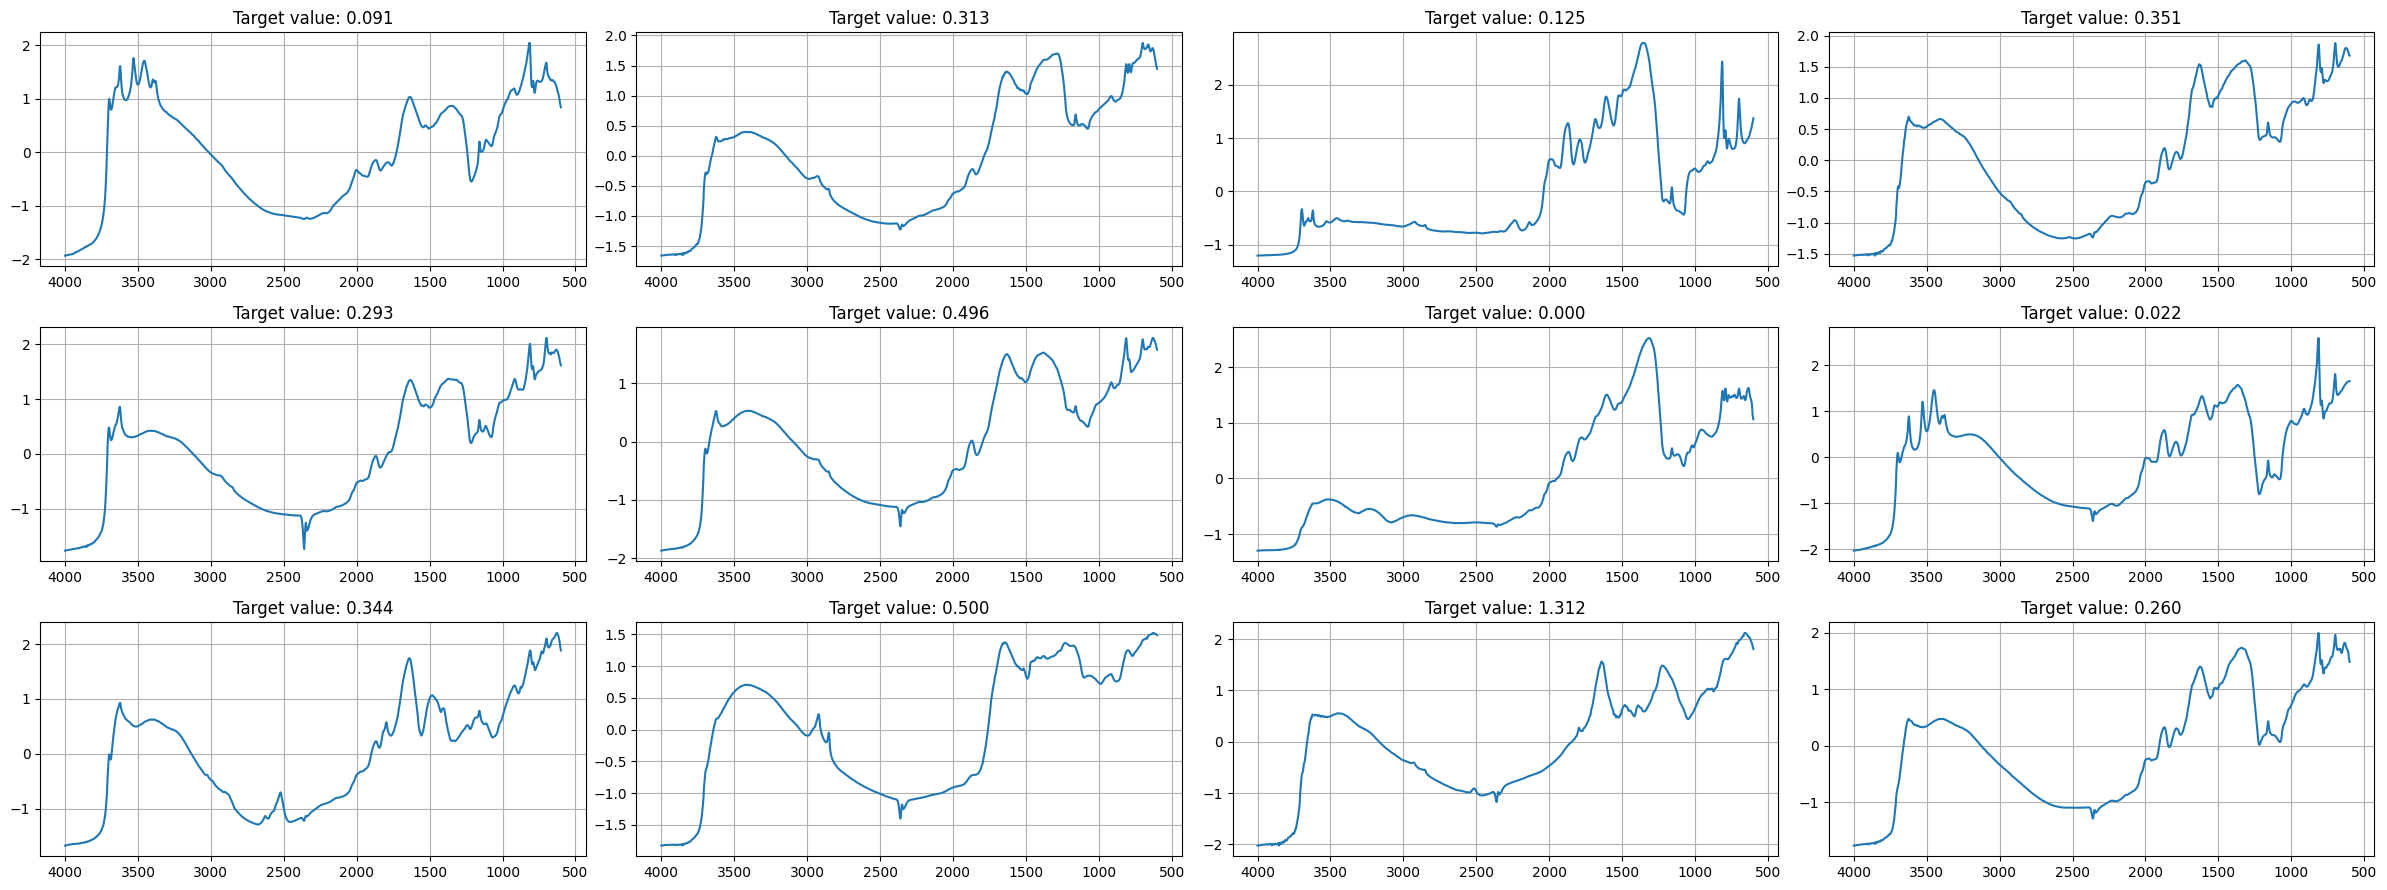

In [21]:
#| eval: false
dls.show_batch(max_n=12, ncols=4)

In [ ]:
#| eval: false
from soilspecai.models import MirzaiCNN
from fastai.callback.schedule import lr_find

In [ ]:
#| eval: false
from fastai.learner import Learner
from fastai.losses import MSELossFlat

learn = Learner(dls, MirzaiCNN(), loss_func=MSELossFlat())
#learn.fit(5)

In [ ]:
#learn.lr_find()

In [ ]:
#| eval: false
from fastai.metrics import R2Score
learn = Learner(dls, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(1, lr_max=2e-3)

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

epoch,train_loss,valid_loss,r2_score,time
0,0.092654,0.068600,-0.741522,00:36


In [ ]:
#| eval: false
test_dl = dls.test_dl([X[i] for i in test_idx])
preds, _ = learn.get_preds(dl=test_dl);

TypeError: __repr__ returned non-string (type NoneType)

TypeError: __repr__ returned non-string (type NoneType)

In [ ]:
#| eval: false
preds

tensor([0.5452, 0.5281, 0.5544, 0.5254, 0.5217, 0.5391, 0.5274, 0.4785, 0.5322,
        0.5388, 0.4823, 0.5089, 0.5139, 0.4920, 0.5304, 0.4861, 0.5387, 0.5597,
        0.4168, 0.5007, 0.4465, 0.4894, 0.3981, 0.5012, 0.5379, 0.5219, 0.5327,
        0.5174, 0.5159, 0.5408, 0.5231, 0.5442, 0.4676, 0.5414, 0.4786, 0.4237,
        0.5017, 0.5202, 0.5493, 0.5361, 0.5026, 0.5366, 0.5414, 0.5066, 0.5154,
        0.5023, 0.5442, 0.5121, 0.5128, 0.4364, 0.5032, 0.5312, 0.3537, 0.5013,
        0.5213, 0.5275, 0.5451, 0.5031, 0.4469, 0.5436, 0.5010, 0.5291, 0.5079,
        0.5418, 0.4615, 0.5459, 0.4970, 0.4576, 0.4725, 0.5047, 0.5311, 0.5383,
        0.5612, 0.4602, 0.5296, 0.4918, 0.5469, 0.4485, 0.3970, 0.4975, 0.5422,
        0.5686, 0.5655, 0.5583, 0.4815, 0.5414, 0.5335, 0.4906, 0.5404, 0.4378,
        0.5045, 0.5194, 0.4431, 0.4818, 0.4541, 0.5123, 0.5219, 0.4937, 0.4915,
        0.4395])

In [ ]:
#| eval: false
from sklearn.metrics import r2_score, mean_squared_error

test_y = y[test_idx]
r2 = r2_score(test_y, preds.numpy().flatten())
rmse = np.sqrt(mean_squared_error(test_y, preds.numpy().flatten()))
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}")

R²: -4.9724, RMSE: 0.5468
